In [7]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers

os.environ["CUDA_VISIBLE_DEVICES"]= "0"

In [8]:
modeldir = "/media/tohn/HDD2/Model_unlearn/ResNet152v2Model/MLunlearn_USAI/R2_unbalanced/unfreeze_conv1-conv3_block/models"
path_model = f"{modeldir}/modelResNet152v2_MLunlearn_USAI_unfreeze_conv1-conv3_block-R2_unbalanced.h5"
model = load_model(path_model)
height = width = model.input_shape[1]
input_shape = (height, width, 3)
print(input_shape)
print("*"*125)
model.summary()

(224, 224, 3)
*****************************************************************************************************************************
Model: "ResNet152v2_unlearnUSAI15ab"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
new_input (InputLayer)       [(None, 224, 224, 3)]     0         
_________________________________________________________________
resnet152v2 (Functional)     (None, None, None, 2048)  58331648  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
prediction_layer (Dense)     (None, 15)                30735     
Total params: 58,362,383
Trainable params: 2,599,055
Non-trainable params: 55,763,328
___________

In [9]:
# validation
import pandas as pd

base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv('/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv('/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v1_Balance_classes.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [10]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [11]:
len(set(dataframe['Sub_class_New']))

15

In [12]:
batch_size = 16

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [13]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

In [14]:
#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    print("[INFO]: Prediced Image >> ", i+1)
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])

[INFO]: Prediced Image >>  1
[INFO]: Prediced Image >>  2
[INFO]: Prediced Image >>  3
[INFO]: Prediced Image >>  4
[INFO]: Prediced Image >>  5
[INFO]: Prediced Image >>  6
[INFO]: Prediced Image >>  7
[INFO]: Prediced Image >>  8
[INFO]: Prediced Image >>  9
[INFO]: Prediced Image >>  10
[INFO]: Prediced Image >>  11
[INFO]: Prediced Image >>  12
[INFO]: Prediced Image >>  13
[INFO]: Prediced Image >>  14
[INFO]: Prediced Image >>  15
[INFO]: Prediced Image >>  16
[INFO]: Prediced Image >>  17
[INFO]: Prediced Image >>  18
[INFO]: Prediced Image >>  19
[INFO]: Prediced Image >>  20
[INFO]: Prediced Image >>  21
[INFO]: Prediced Image >>  22
[INFO]: Prediced Image >>  23
[INFO]: Prediced Image >>  24
[INFO]: Prediced Image >>  25
[INFO]: Prediced Image >>  26
[INFO]: Prediced Image >>  27
[INFO]: Prediced Image >>  28
[INFO]: Prediced Image >>  29
[INFO]: Prediced Image >>  30
[INFO]: Prediced Image >>  31
[INFO]: Prediced Image >>  32
[INFO]: Prediced Image >>  33
[INFO]: Prediced Im

[INFO]: Prediced Image >>  271
[INFO]: Prediced Image >>  272
[INFO]: Prediced Image >>  273
[INFO]: Prediced Image >>  274
[INFO]: Prediced Image >>  275
[INFO]: Prediced Image >>  276
[INFO]: Prediced Image >>  277
[INFO]: Prediced Image >>  278
[INFO]: Prediced Image >>  279
[INFO]: Prediced Image >>  280
[INFO]: Prediced Image >>  281
[INFO]: Prediced Image >>  282
[INFO]: Prediced Image >>  283
[INFO]: Prediced Image >>  284
[INFO]: Prediced Image >>  285
[INFO]: Prediced Image >>  286
[INFO]: Prediced Image >>  287
[INFO]: Prediced Image >>  288
[INFO]: Prediced Image >>  289
[INFO]: Prediced Image >>  290
[INFO]: Prediced Image >>  291
[INFO]: Prediced Image >>  292
[INFO]: Prediced Image >>  293
[INFO]: Prediced Image >>  294
[INFO]: Prediced Image >>  295
[INFO]: Prediced Image >>  296
[INFO]: Prediced Image >>  297
[INFO]: Prediced Image >>  298
[INFO]: Prediced Image >>  299
[INFO]: Prediced Image >>  300
[INFO]: Prediced Image >>  301
[INFO]: Prediced Image >>  302
[INFO]: 

[INFO]: Prediced Image >>  537
[INFO]: Prediced Image >>  538
[INFO]: Prediced Image >>  539
[INFO]: Prediced Image >>  540
[INFO]: Prediced Image >>  541
[INFO]: Prediced Image >>  542
[INFO]: Prediced Image >>  543
[INFO]: Prediced Image >>  544
[INFO]: Prediced Image >>  545
[INFO]: Prediced Image >>  546
[INFO]: Prediced Image >>  547
[INFO]: Prediced Image >>  548
[INFO]: Prediced Image >>  549
[INFO]: Prediced Image >>  550
[INFO]: Prediced Image >>  551
[INFO]: Prediced Image >>  552
[INFO]: Prediced Image >>  553
[INFO]: Prediced Image >>  554
[INFO]: Prediced Image >>  555
[INFO]: Prediced Image >>  556
[INFO]: Prediced Image >>  557
[INFO]: Prediced Image >>  558
[INFO]: Prediced Image >>  559
[INFO]: Prediced Image >>  560
[INFO]: Prediced Image >>  561
[INFO]: Prediced Image >>  562
[INFO]: Prediced Image >>  563
[INFO]: Prediced Image >>  564
[INFO]: Prediced Image >>  565
[INFO]: Prediced Image >>  566
[INFO]: Prediced Image >>  567
[INFO]: Prediced Image >>  568
[INFO]: 

[INFO]: Prediced Image >>  803
[INFO]: Prediced Image >>  804
[INFO]: Prediced Image >>  805
[INFO]: Prediced Image >>  806
[INFO]: Prediced Image >>  807
[INFO]: Prediced Image >>  808
[INFO]: Prediced Image >>  809
[INFO]: Prediced Image >>  810
[INFO]: Prediced Image >>  811
[INFO]: Prediced Image >>  812
[INFO]: Prediced Image >>  813
[INFO]: Prediced Image >>  814
[INFO]: Prediced Image >>  815
[INFO]: Prediced Image >>  816
[INFO]: Prediced Image >>  817
[INFO]: Prediced Image >>  818
[INFO]: Prediced Image >>  819
[INFO]: Prediced Image >>  820
[INFO]: Prediced Image >>  821
[INFO]: Prediced Image >>  822
[INFO]: Prediced Image >>  823
[INFO]: Prediced Image >>  824
[INFO]: Prediced Image >>  825
[INFO]: Prediced Image >>  826
[INFO]: Prediced Image >>  827
[INFO]: Prediced Image >>  828
[INFO]: Prediced Image >>  829
[INFO]: Prediced Image >>  830
[INFO]: Prediced Image >>  831
[INFO]: Prediced Image >>  832
[INFO]: Prediced Image >>  833
[INFO]: Prediced Image >>  834
[INFO]: 

[INFO]: Prediced Image >>  1068
[INFO]: Prediced Image >>  1069
[INFO]: Prediced Image >>  1070
[INFO]: Prediced Image >>  1071
[INFO]: Prediced Image >>  1072
[INFO]: Prediced Image >>  1073
[INFO]: Prediced Image >>  1074
[INFO]: Prediced Image >>  1075
[INFO]: Prediced Image >>  1076
[INFO]: Prediced Image >>  1077
[INFO]: Prediced Image >>  1078
[INFO]: Prediced Image >>  1079
[INFO]: Prediced Image >>  1080
[INFO]: Prediced Image >>  1081
[INFO]: Prediced Image >>  1082
[INFO]: Prediced Image >>  1083
[INFO]: Prediced Image >>  1084
[INFO]: Prediced Image >>  1085
[INFO]: Prediced Image >>  1086
[INFO]: Prediced Image >>  1087
[INFO]: Prediced Image >>  1088
[INFO]: Prediced Image >>  1089
[INFO]: Prediced Image >>  1090
[INFO]: Prediced Image >>  1091
[INFO]: Prediced Image >>  1092
[INFO]: Prediced Image >>  1093
[INFO]: Prediced Image >>  1094
[INFO]: Prediced Image >>  1095
[INFO]: Prediced Image >>  1096
[INFO]: Prediced Image >>  1097
[INFO]: Prediced Image >>  1098
[INFO]: 

In [15]:
print(len(pred_list))
print(len(prob_list))
dataframe['category'] = pred_list
dataframe['Prob'] = prob_list
dataframe

1312
1312


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,Normal,0.975878
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,Normal,0.999906
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.436441
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB01,0.515154
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB01,0.630235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,6550,350,P3,P32,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-B,2,Normal,...,Normal,NaN,NaN,False,Test,P9,P3-2.Case 350.JPG,P9,Normal,0.999993
1308,6551,350,P4,P42,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-B,2,Normal,...,Normal,Easy,Easy,False,Test,P5,P4-2.Case 350.JPG,P5,Normal,0.999968
1309,6552,350,P5,P52,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-C,2,Normal,...,Normal,Easy,Easy,True,Test,None,P5-2.Case 350.JPG,P7,Normal,0.998492
1310,6553,350,P6,P61,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-C,2,Normal,...,Normal,Hard,Easy,True,Test,P14,P6.Case 350.JPG,P14,Normal,0.513406


In [16]:
dataframe.to_csv("/home/kannika/code/Result_ResNet152v2_MLunlearnR1_unfreeze_conv1x-conv3_USAIunbalanced_repeat.csv")

# Evaluation

In [17]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  13
{'AB05', 'AB10', 'Normal', 'AB082', 'AB12', 'AB02', 'AB03', 'AB04', 'AB083', 'AB081', 'AB09', 'AB11', 'AB01'}
Actual :  15
{'AB05', 'AB07', 'AB10', 'Normal', 'AB082', 'AB12', 'AB02', 'AB03', 'AB04', 'AB083', 'AB081', 'AB09', 'AB11', 'AB06', 'AB01'}


In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 75.60975609756098%
              precision    recall  f1-score   support

        AB01       0.92      0.30      0.45        74
        AB02       0.34      0.25      0.29        59
        AB03       0.20      0.47      0.29        19
        AB04       0.46      0.32      0.37        38
        AB05       1.00      0.14      0.24        29
        AB06       0.00      0.00      0.00        21
        AB07       0.00      0.00      0.00        21
       AB081       0.50      0.09      0.16        32
       AB082       0.82      0.32      0.46        28
       AB083       0.33      0.09      0.14        11
        AB09       0.67      0.15      0.25        26
        AB10       1.00      0.10      0.18        10
        AB11       0.73      0.75      0.74        55
        AB12       0.68      0.59      0.63        32
      Normal       0.80      0.99      0.89       857

    accuracy                           0.76      1312
   macro avg       0.56      0.30      

/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 21.5, 'Predicted label')

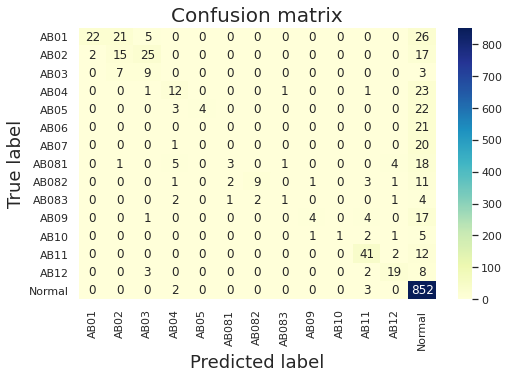

In [19]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [20]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 83.84146341463415%
              precision    recall  f1-score   support

           0       0.80      0.99      0.89       857
           1       0.98      0.55      0.70       455

    accuracy                           0.84      1312
   macro avg       0.89      0.77      0.79      1312
weighted avg       0.87      0.84      0.82      1312



TN = 852, FP = 5, FN = 207, TP = 248
*****************************************************************************************************************************


Text(48.5, 0.5, 'True label')

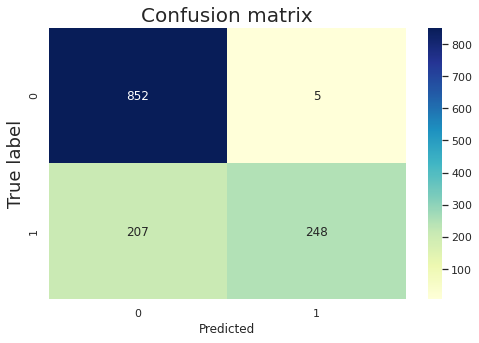

In [21]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(f"TN = {TN}, FP = {FP}, FN = {FN}, TP = {TP}")
print("*"*125)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [22]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB05
classifier accuracy = 0.13793103448275862% 

###### AB07
classifier accuracy = 0.0% 

###### AB10
classifier accuracy = 0.1% 

###### Normal
classifier accuracy = 0.9941656942823804% 

###### AB082
classifier accuracy = 0.32142857142857145% 

###### AB12
classifier accuracy = 0.59375% 

###### AB02
classifier accuracy = 0.2542372881355932% 

###### AB03
classifier accuracy = 0.47368421052631576% 

###### AB04
classifier accuracy = 0.3157894736842105% 

###### AB083
classifier accuracy = 0.09090909090909091% 

###### AB081
classifier accuracy = 0.09375% 

###### AB09
classifier accuracy = 0.15384615384615385% 

###### AB11
classifier accuracy = 0.7454545454545455% 

###### AB06
classifier accuracy = 0.0% 

###### AB01
classifier accuracy = 0.2972972972972973% 



# Exclude Normal classes

In [23]:
dataframe0_ = dataframe[(dataframe["Sub_class_New"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_

(248, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.436441
1,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB01,0.515154
2,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB01,0.630235
3,116,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,ModerateFattyLiver,...,AB02,NaN,NaN,False,Test,P1,AB02 P1 C040.JPG,P1,AB03,0.547013
4,117,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,ModerateFattyLiver,...,AB02,Hard,Easy,False,Test,P4,AB02 P4-1 C040.JPG,P4,AB02,0.884847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,2246,442,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,RenalstonesHydronephrosis,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 284.JPG.png,P12,AB11,0.974559
244,2247,301,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,RenalCyst,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 143.JPG.png,P12,AB11,0.490426
245,2253,300,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 142.JPG.png,P12,AB12,0.968496
246,2265,361,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Hydronephrosis,...,AB11,Easy,Hard,False,Test,P12,FP D P7-2 Case 203.JPG.png,P12,AB11,0.920726


In [24]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  12
{'AB05', 'AB10', 'AB082', 'AB12', 'AB02', 'AB03', 'AB04', 'AB083', 'AB081', 'AB09', 'AB11', 'AB01'}
Actual :  13
{'AB05', 'AB07', 'AB10', 'AB082', 'AB12', 'AB02', 'AB03', 'AB04', 'AB083', 'AB081', 'AB09', 'AB11', 'AB01'}


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 56.45161290322581%
              precision    recall  f1-score   support

        AB01       0.92      0.46      0.61        48
        AB02       0.34      0.36      0.35        42
        AB03       0.20      0.56      0.30        16
        AB04       0.50      0.80      0.62        15
        AB05       1.00      0.57      0.73         7
        AB07       0.00      0.00      0.00         1
       AB081       0.50      0.21      0.30        14
       AB082       0.82      0.53      0.64        17
       AB083       0.33      0.14      0.20         7
        AB09       0.67      0.44      0.53         9
        AB10       1.00      0.20      0.33         5
        AB11       0.77      0.95      0.85        43
        AB12       0.68      0.79      0.73        24

    accuracy                           0.56       248
   macro avg       0.59      0.46      0.48       248
weighted avg       0.64      0.56      0.57       248



/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 21.5, 'Predicted label')

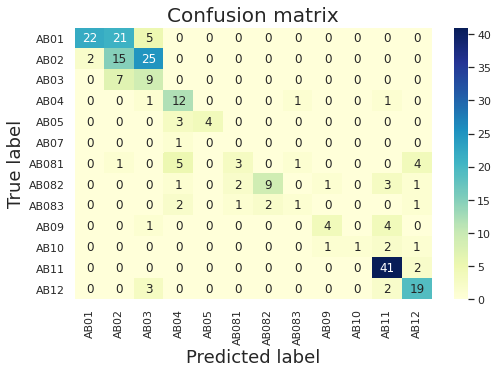

In [26]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)